# Figure 5

## Generate Figure 5


N = 1066
(a) LMP                       R2 = 0.6751
(b) Basic fractal (d=0.331)   R2 = 0.8719
(c) Temperature-dependent      R2 = 0.9004
(d) Proposed (sigma*_T + ML)    R2 = 0.9474


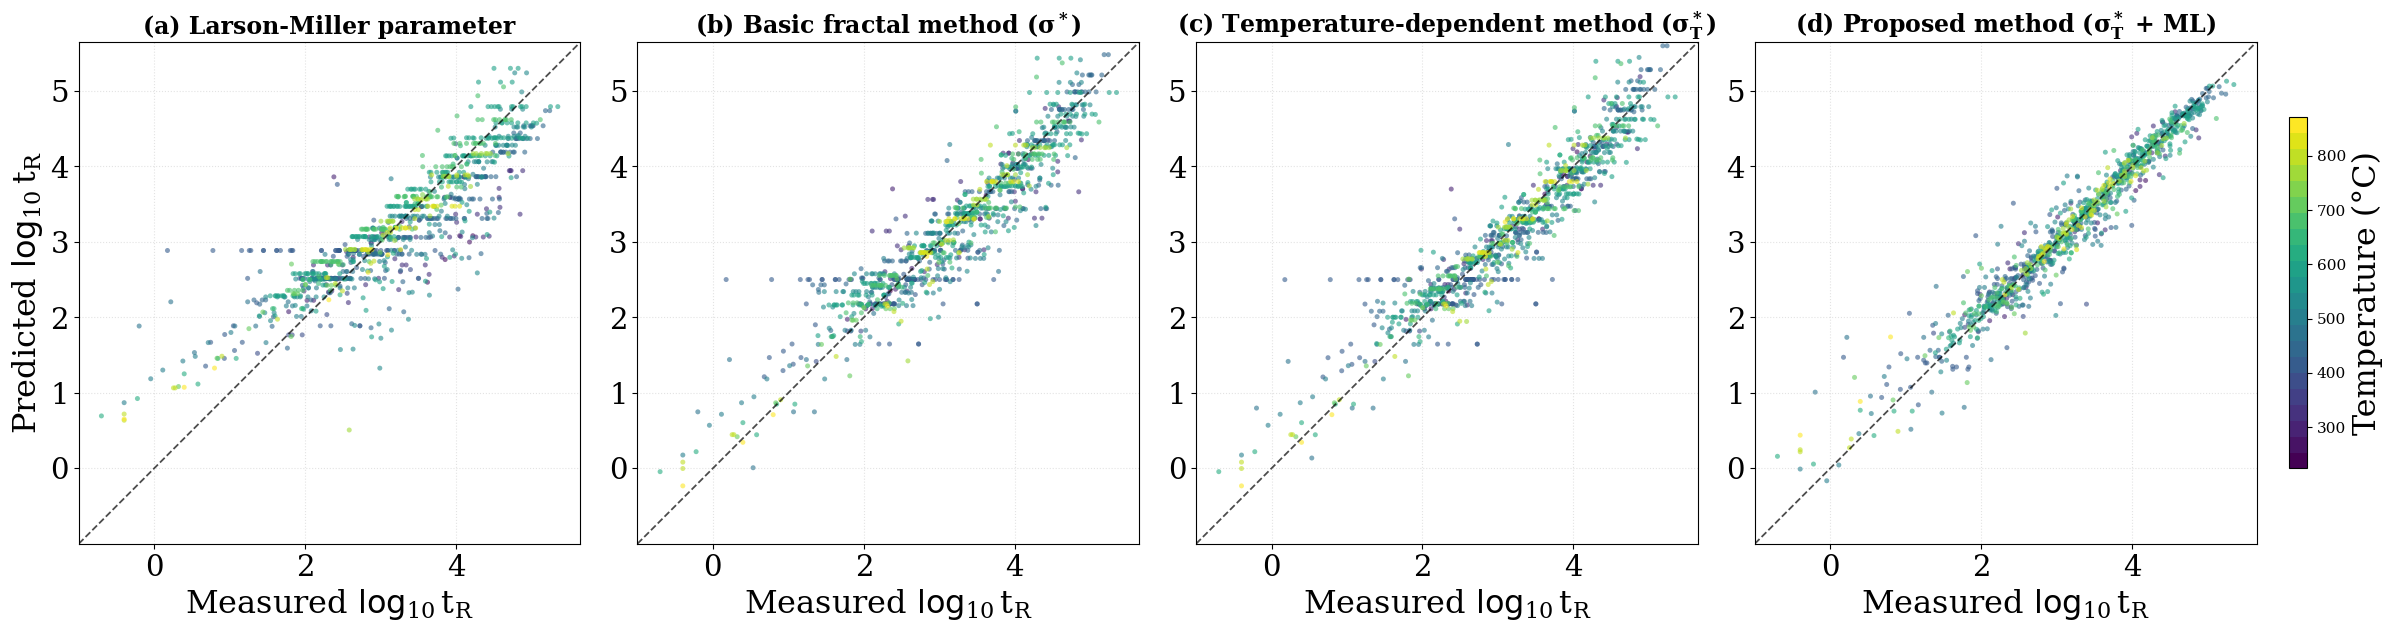

In [1]:
"""
Four-panel parity plot for SS316H creep rupture life prediction.
"""

import os
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import linregress
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.base import clone
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ----------------------------------------------------------------------
# 0. Settings
# ----------------------------------------------------------------------
DATA_PATH = os.path.join("..", "Dataset", "Creep_Properties_Dataset.xlsx")

LABEL_SIZE = 23
TICK_SIZE  = 21
TITLE_SIZE = 17

COMP = ["C, wt.%", "Si, wt.%", "Mn, wt.%", "P, wt.%", "S, wt.%", "Ni, wt.%",
        "Cr, wt.%", "Mo, wt.%", "Al, wt.%", "N, wt.%", "Ti, wt.%", "Fe, wt.%",
        "Nb, wt.%", "B, wt.%", "Cu, wt.%", "Co, wt.%"]

b0, A0, LD0 = 8.0, 48.0, 5.0

plt.rcParams.update({
    "mathtext.default":  "regular",
    "font.family":       "serif",
    "axes.labelsize":    LABEL_SIZE,
    "axes.titlesize":    TITLE_SIZE,
    "xtick.labelsize":   TICK_SIZE,
    "ytick.labelsize":   TICK_SIZE,
})

# ----------------------------------------------------------------------
# 1. Load and filter SS316H
# ----------------------------------------------------------------------
df = pd.read_excel(DATA_PATH, header=1)
mask = ((df["Alloy Designation"] == "SS316H") &
        df["Creep Rupture Life (h)"].notna() &
        (df["Creep Rupture Life (h)"] > 0) &
        (df["Stress (Mpa)"] > 0) &
        df["Specimen Shape"].isin(["Flat", "Cylindrical"]))
data = df[mask].copy().reset_index(drop=True)
data["log_tR"] = np.log10(data["Creep Rupture Life (h)"])

need = (["Stress (Mpa)", "Temperature of Creep Test (C)", "Thickness (mm)",
         "Cross-Sectional Area", "Aspect Ratio (L/D)"] + COMP + ["log_tR"])
sub = data.dropna(subset=need).reset_index(drop=True)
sub = sub[(sub["Thickness (mm)"] > 0) &
          (sub["Cross-Sectional Area"] > 0) &
          (sub["Aspect Ratio (L/D)"] > 0)].reset_index(drop=True)

y    = sub["log_tR"].values.astype(float)
sig  = sub["Stress (Mpa)"].values
T    = sub["Temperature of Creep Test (C)"].values
b    = sub["Thickness (mm)"].values
A    = sub["Cross-Sectional Area"].values
LD   = sub["Aspect Ratio (L/D)"].values
comp = sub[COMP].values.astype(float)
TK   = T + 273.15
Tn   = (T - T.mean()) / T.std()
print(f"N = {len(y)}")

# ----------------------------------------------------------------------
# 2. Helpers
# ----------------------------------------------------------------------
def predict_perT(stress_descriptor):
    x = np.log10(stress_descriptor)
    pred = np.full_like(y, np.nan)
    for t in np.unique(T):
        m = (T == t)
        if m.sum() >= 3:
            sl, ic, *_ = linregress(x[m], y[m])
            pred[m] = sl * x[m] + ic
        else:
            pred[m] = y[m].mean()
    return pred

def r2(pred):
    ss_res = np.nansum((y - pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return 1 - ss_res / ss_tot

# ----------------------------------------------------------------------
# 3. (a) Larson-Miller parameter
# ----------------------------------------------------------------------
def lmp_pred(C):
    P = TK * (C + np.log10(10 ** y))
    x = np.log10(sig)
    coef = np.polyfit(x, P, 2)
    Ppred = np.polyval(coef, x)
    return Ppred / TK - C

best = None
for C in np.arange(10, 30, 0.5):
    p = lmp_pred(C)
    r = r2(p)
    if best is None or r > best[0]:
        best = (r, C, p)
pred_a = best[2]
print(f"(a) LMP                       R2 = {r2(pred_a):.4f}")

# ----------------------------------------------------------------------
# 4. (b) Basic fractal
# ----------------------------------------------------------------------
d_opt = minimize(lambda d: -r2(predict_perT(sig * b ** d[0])),
                 x0=[0.05], method="Nelder-Mead").x[0]
pred_b = predict_perT(sig * b ** d_opt)
print(f"(b) Basic fractal (d={d_opt:.3f})   R2 = {r2(pred_b):.4f}")

# ----------------------------------------------------------------------
# 5. (c) Temperature-dependent geometry-corrected stress
# ----------------------------------------------------------------------
def sigmaT(p):
    a0, a1, be0, be1, g0, g1 = p
    a  = a0 + a1 * Tn
    be = be0 + be1 * Tn
    g  = g0 + g1 * Tn
    return sig * (b / b0) ** a * (A / A0) ** be * (LD / LD0) ** g

p_opt = minimize(lambda p: -r2(predict_perT(sigmaT(p))),
                 x0=[-0.025, 0, 0.016, 0, -0.129, 0],
                 method="Nelder-Mead",
                 options={"maxiter": 8000}).x
sig_star_T = sigmaT(p_opt)
pred_c = predict_perT(sig_star_T)
print(f"(c) Temperature-dependent      R2 = {r2(pred_c):.4f}")

# ----------------------------------------------------------------------
# 6. (d) Proposed method: sigma*_T + GBM (5-fold CV)
# ----------------------------------------------------------------------
X = np.column_stack([np.log10(sig_star_T), T, comp])
gbm = lambda: GradientBoostingRegressor(
    n_estimators=500, max_depth=5, learning_rate=0.03,
    subsample=0.8, min_samples_leaf=3, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
pred_d = np.zeros_like(y)
for tr, te in kf.split(X):
    m = clone(gbm()); m.fit(X[tr], y[tr]); pred_d[te] = m.predict(X[te])
print(f"(d) Proposed (sigma*_T + ML)    R2 = {r2(pred_d):.4f}")

# ----------------------------------------------------------------------
# 7. Plot
# ----------------------------------------------------------------------
panels = [
    (pred_a, r"(a) Larson-Miller parameter"),
    (pred_b, r"(b) Basic fractal method ($\sigma^*$)"),
    (pred_c, r"(c) Temperature-dependent method ($\sigma^*_T$)"),
    (pred_d, r"(d) Proposed method ($\sigma^*_T$ + ML)"),
]

temps  = sorted(np.unique(T))
cmap   = plt.get_cmap("viridis", len(temps))
tcolor = {t: cmap(i) for i, t in enumerate(temps)}

fig, axes = plt.subplots(1, 4, figsize=(24, 6.0), constrained_layout=True)
lims = [y.min() - 0.3, y.max() + 0.3]

for i, (ax, (pred, title)) in enumerate(zip(axes, panels)):
    for t in temps:
        m = (T == t)
        ax.scatter(y[m], pred[m], c=[tcolor[t]], s=13, alpha=0.6, edgecolors="none")
    ax.plot(lims, lims, "k--", lw=1.3, alpha=0.7)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect("equal")
    ax.set_xlabel(r"Measured $\log_{10} t_R$")
    if i == 0:
        ax.set_ylabel(r"Predicted $\log_{10} t_R$")
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=True)   # keep tick numbers, just no label
    ax.set_title(title, fontweight="bold")
    ax.grid(True, ls=":", alpha=0.35)

sm   = plt.cm.ScalarMappable(cmap=cmap,
                              norm=plt.Normalize(vmin=min(temps), vmax=max(temps)))
cbar = fig.colorbar(sm, ax=axes, fraction=0.014, pad=0.015, shrink=0.7)
cbar.set_label("Temperature (°C)", fontsize=LABEL_SIZE)
cbar.ax.tick_params(labelsize=11)

plt.show()
